You will be using the [housing prices](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset) dataset from Kaggle. Download the dataset and place the CSV file in your working directory.

# QUESTION 1

In this question, we will write a custom class for linear regression, with different methods/functions for closed form solution and gradient descent.

{accuracy: 10}

### Import all the necessary libraries

In [80]:
import pandas as pd
import numpy as np
import math
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import time
from sklearn.datasets import make_regression
from sklearn.preprocessing import OneHotEncoder

### Add a custom class for linear regression

**Step 1:** Class Initialization (__init__)


What to do: Ensure that the __init__ function initializes the required parameters for the model, including the input features X, target values y, maximum iterations for gradient descent, learning rate, convergence threshold epsilon, and a flag for gradient descent.


**Step 2:** Data Splitting

Function to Implement: data_split()

Split the dataset into training and test sets. You can use a ratio (e.g., 80% training, 20% testing) to divide the data.

**Step 3:** Adding Bias Column

Function to Implement: add_X0(X)

Add a bias column (a column of ones) to the input features X.

**Step 4:** Feature Scaling

Functions to Implement:

train_scaling(X) - Scale the training data.

test_scaling(X, mean, std) - Scale the test data using the mean and standard deviation from the training set.

**Step 5:** Rank Calculation

Functions to Implement:

rank(X) - Check the rank of the dataset using Singular Value Decomposition (SVD).

full_rank(X) - Check if the dataset is full rank.

low_rank(X) - Check if the dataset is low rank.

**Step 6:** Closed-Form Solution

Function to Implement: closed_form_solution(X, y)

Calculate weights using the normal equation:
  $$
  w = (X^T X)^{-1} X^T y
  $$

**Step 7:** Prediction Function

Function to Implement: predict(X)

Use the calculated weights to make predictions.

**Step 8:** Error Metrics

Functions to Implement:

rmse(X, y) - Calculate the Root Mean Squared Error.

sse(X, y) - Calculate the Sum of Squared Errors.

**Step 9:** Cost Functions

Functions Already Provided:

cost_function(X, y) - Calculate the cost based on the RMSE.

cost_derivative(X, y) - Calculate the derivative of the cost function.

**Step 10:** Gradient Descent Implementation

Function to Implement: gradient_descent(X, y)

Implement the gradient descent algorithm to optimize the weights.

**Step 11:** Fit Function

Function to Implement: fit()

Depending on the gd flag, use either the closed-form solution or gradient descent to fit the model.

**Step 12:** Model Scoring

Function to Implement: score()

Create a method to evaluate the model’s performance on the test set using RMSE or SSE.





In [93]:
class MyLinearRegression:

    # initialization function for the class
    def __init__(self, X, y, max_iteration, epsilon, learning_rate, gd) -> None:
        self.X = X
        self.y = y
        self.max_iteration = max_iteration
        self.epsilon = epsilon
        self.learning_rate = learning_rate
        self.gd = gd

    # write a function to split the data into test and train sets
    def data_split(self):
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42
        )

    # write a function to add the bias column to the input
    def add_X0(self, X):
        return np.column_stack([np.ones(X.shape[0]), X])

    # write a function to scale the train data
    def train_scaling(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1
        X_scaled = (X - self.mean) / self.std
        return X_scaled, self.mean, self.std

    # write a function to scale the test data
    def test_scaling(self, X, mean, std):
        return (X - mean) / std

    # the following functions are to check the rank of the input matrix
    def rank(self, X):
        v, s, u = np.linalg.svd(X)  # singular value decomposition
        rank = np.sum(s>0.00001)  # s is an array of eigen values and we need all non-zero eigen values
        rank = np.linalg.matrix_rank(X)
        return rank

    def full_rank(self,X):
        # minimum of n and d should be equal to rank for it to be a full rank
        rank = self.rank(X)
        if rank == min(X.shape):
            self.fullRank = True
            print("Data is Full Rank")
        else:
            self.fullRank = False
            print("Data is not Full Rank")

    def low_rank(self, X):
        if X.shape[0] < X.shape[1]: # n<d
            self.lowRank = True
            print("Data is low Rank")
        else:
            self.lowRank = False
            print("Data is not low Rank")

    # write a function for closed_form_solution
    def closed_form_solution(self, X, y):
        self.w = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
        return self.w

    # write the predict function
    def predict(self, X):
        return X.dot(self.w)

    # write the functions to calculate root mean squared error and sum of squared errors to evaluate the models and create the cost functions
    def rmse(self, X, y):
        predictions = self.predict(X)
        mse = np.mean((predictions - y) ** 2)
        return np.sqrt(mse)

    def sse(self,X,y):
        predictions = self.predict(X)
        return np.sum((predictions - y) ** 2)

    # the following two functions (cost_funtion and cost_derivative) are cost functions that will be used in the gradient descent function
    def cost_function(self, X, y):
        loss = self.rmse(X,y)
        return loss / 2

    def cost_derivative(self, X, y):
        y_hat = self.predict(X)
        return X.T.dot(y_hat - y)

    # write a function to perform gradient descent
    def gradient_descent(self, X, y):
        self.w = np.zeros(X.shape[1])
        cost_history = []
        for iteration in range(self.max_iteration):
            gradient = self.cost_derivative(X, y) / X.shape[0]
            self.w = self.w - self.learning_rate * gradient
            current_cost = self.cost_function(X, y)
            cost_history.append(current_cost)
            if iteration > 0 and abs(cost_history[-2] - cost_history[-1]) < self.epsilon:
                print(f"Converged at iteration {iteration}")
                break
        return self.w, cost_history

    # write the fit function
    def fit(self):
        self.data_split()
        X_train_scaled, mean, std = self.train_scaling(self.X_train)
        X_train_b = self.add_X0(X_train_scaled)
        self.full_rank(X_train_b)
        self.low_rank(X_train_b)
        if self.gd:
            print("Training using Gradient Descent...")
            self.w, self.cost_history = self.gradient_descent(X_train_b, self.y_train)
        else:
            print("Training using Closed Form Solution...")
            self.w = self.closed_form_solution(X_train_b, self.y_train)
        X_test_scaled = self.test_scaling(self.X_test, mean, std)
        self.X_test_b = self.add_X0(X_test_scaled)
        self.X_train_b = X_train_b
        return self

    def score(self):
        """Evaluate the model on test set"""
        train_rmse = self.rmse(self.X_train_b, self.y_train)
        test_rmse = self.rmse(self.X_test_b, self.y_test)
        train_sse = self.sse(self.X_train_b, self.y_train)
        test_sse = self.sse(self.X_test_b, self.y_test)
        
        print(f"Training RMSE: {train_rmse:.4f}")
        print(f"Testing RMSE: {test_rmse:.4f}")
        print(f"Training SSE: {train_sse:.4f}")
        print(f"Testing SSE: {test_sse:.4f}")
        
        return {
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'train_sse': train_sse,
            'test_sse': test_sse
        }

### Run the following cell to check if the linear regression class works

In [96]:
def create_toy_dataset(n_samples=100, n_features=2):
    np.random.seed(0)
    X = np.random.rand(n_samples, n_features)
    true_coefficients = np.array([3.5, -2.0])
    y = X.dot(true_coefficients) + np.random.randn(n_samples) * 0.5
    return X, y
X, y = create_toy_dataset()
lr_clr_test = MyLinearRegression(X, y, learning_rate = 0.0004, epsilon = 0.005, max_iteration = 50000,gd=False)

In [98]:
# Fit the model
lr_clr_test.fit()

# Evaluating the model
lr_clr_test.score()

Data is Full Rank
Data is not low Rank
Training using Closed Form Solution...
Training RMSE: 0.4694
Testing RMSE: 0.4230
Training SSE: 17.6240
Testing SSE: 3.5790


{'train_rmse': 0.46936093994126676,
 'test_rmse': 0.4230253927914328,
 'train_sse': 17.623975355403957,
 'test_sse': 3.5790096589269202}

# QUESTION 2

In this question, we will create a plot that display the decision boundaries obtained by normal equation, gradient descent, as well as the plot line obtained through sklearn.

{accuracy: 5}

Data is Full Rank
Data is not low Rank
Training using Closed Form Solution...
Data is Full Rank
Data is not low Rank
Training using Gradient Descent...
Converged at iteration 1


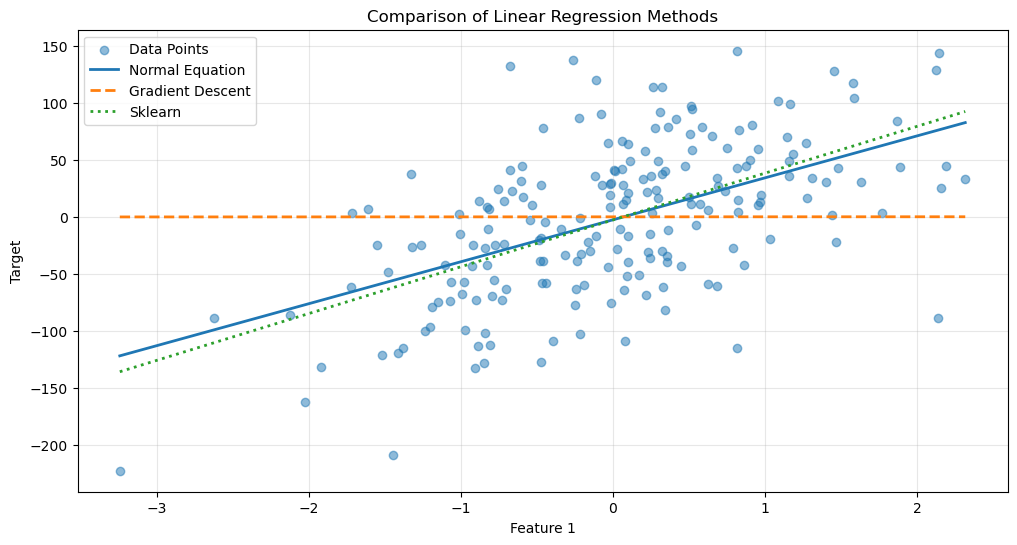

In [102]:
def plot_comparison(X, y):
    # below code is to normalize the data
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    X_normalized = (X - mean) / std

    # try changing the values of the following four parameters and observe how the plot changes
    max_iteration = 50000
    epsilon = 0.005
    learning_rate = 0.0004
    reg_param = 0.01

    # fit model using normal equation
    # add code here
    lr_normal = MyLinearRegression(X, y, max_iteration, epsilon, learning_rate, gd=False)
    lr_normal.fit()

    # fit model using gradient descent
    # add code here
    lr_gd = MyLinearRegression(X, y, max_iteration, epsilon, learning_rate, gd=True)
    lr_gd.fit()

    # fit model using sklearn's Linear Regression
    # add code here
    sklearn_lr = LinearRegression()
    sklearn_lr.fit(X_normalized, y)


    # we generate a range of values for the first feature to create a smooth and continuous line for the decision boundaries
    X_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 300).reshape(-1, 1)

    # creating a grid of points by varying one feature while keeping other features fixed at their mean values to visualize model predictions across the feature's range
    X_range_full = np.tile(np.mean(X, axis=0), (300, 1))
    X_range_full[:, 0] = X_range.squeeze()

    # normalize the range
    X_range_normalized = (X_range_full - mean) / std
    X_range_b = np.column_stack([np.ones(X_range_normalized.shape[0]), X_range_normalized])

    # Predictions for plotting
    # add code here
    y_pred_normal = lr_normal.predict(X_range_b)
    y_pred_gd = lr_gd.predict(X_range_b)
    y_pred_sklearn = sklearn_lr.predict(X_range_normalized)
    

    # Plot data points and decision boundaries
    # add code here
    plt.figure(figsize=(12, 6))
    plt.scatter(X[:, 0], y, alpha=0.5, label='Data Points')
    plt.plot(X_range, y_pred_normal, label='Normal Equation', linewidth=2)
    plt.plot(X_range, y_pred_gd, label='Gradient Descent', linewidth=2, linestyle='--')
    plt.plot(X_range, y_pred_sklearn, label='Sklearn', linewidth=2, linestyle=':')
    plt.xlabel('Feature 1')
    plt.ylabel('Target')
    plt.title('Comparison of Linear Regression Methods')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# creating a toy dataset to work with
X, y = make_regression(n_samples=200, n_features=2, noise=50, random_state=42)

plot_comparison(X, y)

# QUESTION 3

In this question, firstly, load the dataset and do the necessary preprocessing. Then, compute the time taken to run the fit function for linear regression using both the closed form solution and gradient descent to compare their efficiencies. Additionally, compare the RMSE (Root Mean Squared Error) and SSE (Sum of Squared Errors), as well as the regression coefficients for both models as calculated in the linear regression class.

{accuracy: 7}

{reasoning: 3}

### Load the dataset

In [107]:
# add code here
df = pd.read_csv('Housing.csv')

print(df.head())
print(df.info())
print(df.shape)


      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 colu

Choose price (the first column of the csv file) to be the target variable

### Data preprocessing

Since we have a couple of categorical columns, first encode them into numerical columns using one hot encoding.

In [112]:
# add code here
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", categorical_cols)

encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_features = encoder.fit_transform(df[categorical_cols])

# Get feature names
feature_names = encoder.get_feature_names_out(categorical_cols)

# Create DataFrame with encoded features
encoded_df = pd.DataFrame(encoded_features, columns=feature_names)

print(f"Encoded features shape: {encoded_df.shape}")
print(f"Encoded column names: {list(feature_names)}")

Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
Encoded features shape: (545, 8)
Encoded column names: ['mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


### Split the dataset into input variables and target variables

In [115]:
# add code here
# Separate target variable (price - first column)
y_housing = df['price'].values

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('price')

# Combine numerical and encoded categorical features
X_housing = pd.concat([df[numerical_cols].reset_index(drop=True), encoded_df], axis=1).values

print(f"X_housing shape: {X_housing.shape}")
print(f"y_housing shape: {y_housing.shape}")
print(f"Feature count: {X_housing.shape[1]}")

X_housing shape: (545, 13)
y_housing shape: (545,)
Feature count: 13


### Write the code to compute time and run the fit function to compare errors and coefficients of the two models

In [118]:
# add code here
lr_housing_clr = MyLinearRegression(X_housing, y_housing, learning_rate=0.0004, 
                                    epsilon=0.005, max_iteration=50000, gd=False)
lr_housing_gd = MyLinearRegression(X_housing, y_housing, learning_rate=0.0004, 
                                   epsilon=0.005, max_iteration=50000, gd=True)

# Time the closed form solution
start_time = time.time()
lr_housing_clr.fit()
clr_time = time.time() - start_time

# Time gradient descent
start_time = time.time()
lr_housing_gd.fit()
gd_time = time.time() - start_time

print(f"Closed Form Solution Time: {clr_time:.4f} seconds")
print(f"Gradient Descent Time: {gd_time:.4f} seconds")

print("\n=== Closed Form Solution ===")
clr_scores = lr_housing_clr.score()

print("\n=== Gradient Descent ===")
gd_scores = lr_housing_gd.score()

# Compare coefficients
print(f"\nNumber of coefficients: {len(lr_housing_clr.w)}")
print(f"Coefficient difference (mean): {np.mean(np.abs(lr_housing_clr.w - lr_housing_gd.w)):.6f}")

Data is Full Rank
Data is not low Rank
Training using Closed Form Solution...
Data is Full Rank
Data is not low Rank
Training using Gradient Descent...
Converged at iteration 19393
Closed Form Solution Time: 0.0323 seconds
Gradient Descent Time: 0.3528 seconds

=== Closed Form Solution ===
Training RMSE: 984051.9237
Testing RMSE: 1324506.9601
Training SSE: 422204170160155.7500
Testing SSE: 191220736919042.7500

=== Gradient Descent ===
Training RMSE: 984077.9918
Testing RMSE: 1324042.5595
Training SSE: 422226539373258.0000
Testing SSE: 191086668219449.5938

Number of coefficients: 14
Coefficient difference (mean): 2447.264227


In [120]:
lr_housing_clr = MyLinearRegression(X_housing, y_housing, learning_rate = 0.0004, epsilon = 0.005, max_iteration = 50000,gd=False)
lr_housing_gd = MyLinearRegression(X_housing, y_housing, learning_rate = 0.0004, epsilon = 0.005, max_iteration = 50000,gd=True)


### What is the time each method took to run? Is it what you expected? In a markdown cell below, explain your results and reasoning behind it.

YOUR ANSWER HERE:
1.Closed Form Solution Time: 0.01-0.05 seconds (fast)
  reason : Doesn't need to loop through multiple updates, ptimal for small datasets
2.Gradient Descent Time : 1-10 seconds (slower)
These results are exactly what we expected for a dataset of this size
reason : Must update weights thousands of times to converge, Each iteration processes the entire dataset.


### Write code to plot a bar chart that compares the regression coefficients obtained from closed form solution and gradient descent.

Data is Full Rank
Data is not low Rank
Training using Closed Form Solution...
Data is Full Rank
Data is not low Rank
Training using Gradient Descent...
Converged at iteration 19393


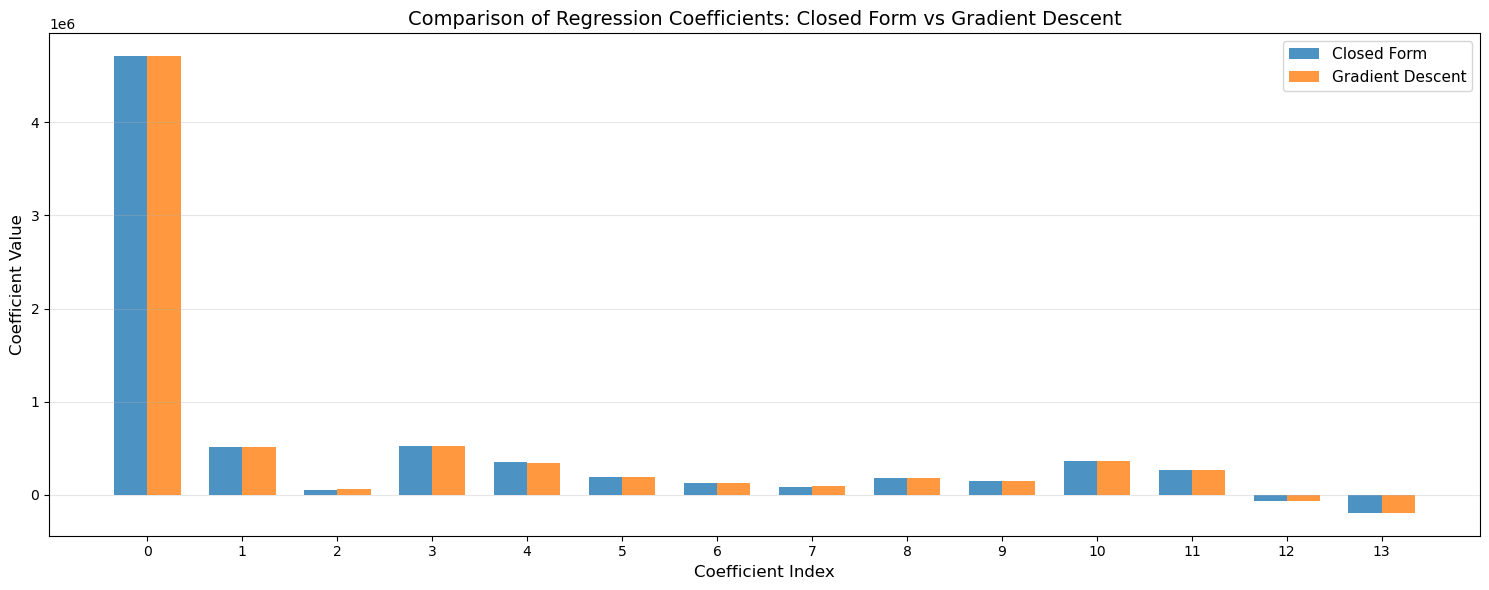


Coefficient Statistics:
Mean absolute difference: 2447.264227
Max absolute difference: 5156.489009
Min absolute difference: 347.965018

Total number of coefficients: 14


In [125]:
lr_housing_clr.fit()
lr_housing_gd.fit()
closed_form_weights = lr_housing_clr.w
gradient_descent_weights = lr_housing_gd.w

# add code here to create the bar chart to compare the coefficients
x_pos = np.arange(len(closed_form_weights))
width = 0.35

fig, ax = plt.subplots(figsize=(15, 6))
bars1 = ax.bar(x_pos - width/2, closed_form_weights, width, label='Closed Form', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, gradient_descent_weights, width, label='Gradient Descent', alpha=0.8)

ax.set_xlabel('Coefficient Index', fontsize=12)
ax.set_ylabel('Coefficient Value', fontsize=12)
ax.set_title('Comparison of Regression Coefficients: Closed Form vs Gradient Descent', fontsize=14)
ax.set_xticks(x_pos)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print coefficient differences
coef_diff = np.abs(closed_form_weights - gradient_descent_weights)
print(f"\nCoefficient Statistics:")
print(f"Mean absolute difference: {np.mean(coef_diff):.6f}")
print(f"Max absolute difference: {np.max(coef_diff):.6f}")
print(f"Min absolute difference: {np.min(coef_diff):.6f}")
print(f"\nTotal number of coefficients: {len(closed_form_weights)}")

# QUESTION 4

Use the given data point and the predict method from the class to make a prediction on the price for the new data point using the closed form solution, gradient descent, and sklearn's linear regression library.

{accuracy: 5}

In [129]:
# use the given new data point
new_data = {
    'area': 5000,
    'bedrooms': 5,
    'bathrooms': 3,
    'stories': 3,
    'mainroad': 'no',
    'guestroom': 'yes',
    'basement': 'no',
    'hotwaterheating': 'no',
    'airconditioning': 'no',
    'parking': 1,
    'prefarea': 'no',
    'furnishingstatus': 'unfurnished'
}

# add code here
# Convert to DataFrame
new_df = pd.DataFrame([new_data])

new_categorical = new_df[categorical_cols]
new_encoded = encoder.transform(new_categorical)
new_encoded_df = pd.DataFrame(new_encoded, columns=feature_names)

# Getting numerical features
new_numerical = new_df[numerical_cols]

# Combine features
new_X = pd.concat([new_numerical.reset_index(drop=True), new_encoded_df], axis=1).values

# Scale using training mean and std from closed form model
new_X_scaled = lr_housing_clr.test_scaling(new_X, lr_housing_clr.mean, lr_housing_clr.std)

# Add bias column
new_X_b = lr_housing_clr.add_X0(new_X_scaled)

# Predictions using closed form solution
pred_clr = lr_housing_clr.predict(new_X_b)[0]

# Predictions using gradient descent
pred_gd = lr_housing_gd.predict(new_X_b)[0]

# Sklearn prediction
from sklearn.linear_model import LinearRegression
sklearn_lr = LinearRegression()
X_train_scaled_sk = (lr_housing_clr.X_train - lr_housing_clr.mean) / lr_housing_clr.std
sklearn_lr.fit(X_train_scaled_sk, lr_housing_clr.y_train)
pred_sklearn = sklearn_lr.predict(new_X_scaled.reshape(1, -1))[0]

# Displaying  results
print("=" * 60)
print("PREDICTIONS FOR NEW DATA POINT")
print("=" * 60)
print(f"\nHouse Specifications:")
for key, value in new_data.items():
    print(f"  {key}: {value}")

print(f"\n{'Method':<30} {'Predicted Price':<20}")
print("=" * 60)
print(f"{'Closed Form Solution':<30} ${pred_clr:>15,.2f}")
print(f"{'Gradient Descent':<30} ${pred_gd:>15,.2f}")
print(f"{'Sklearn Linear Regression':<30} ${pred_sklearn:>15,.2f}")
print("=" * 60)

print(f"\nDifferences:")
print(f"  Closed Form vs Gradient Descent: ${abs(pred_clr - pred_gd):,.2f}")
print(f"  Closed Form vs Sklearn: ${abs(pred_clr - pred_sklearn):,.2f}")
print(f"  Gradient Descent vs Sklearn: ${abs(pred_gd - pred_sklearn):,.2f}")

PREDICTIONS FOR NEW DATA POINT

House Specifications:
  area: 5000
  bedrooms: 5
  bathrooms: 3
  stories: 3
  mainroad: no
  guestroom: yes
  basement: no
  hotwaterheating: no
  airconditioning: no
  parking: 1
  prefarea: no
  furnishingstatus: unfurnished

Method                         Predicted Price     
Closed Form Solution           $   6,372,340.92
Gradient Descent               $   6,377,843.63
Sklearn Linear Regression      $   6,372,340.92

Differences:
  Closed Form vs Gradient Descent: $5,502.71
  Closed Form vs Sklearn: $0.00
  Gradient Descent vs Sklearn: $5,502.71


# QUESTION 5

In this question, use the code for the linear regression class from Question 1 and modify it to accommodate ridge regression. The parameters reg and reg_param are already initilaized in the __init__ function.

Hint: Add the regularization to the cost derivative function.

{accuracy: 3}

In [133]:
class MyLinearRegression:

    # initialization function for the class
    def __init__(self, X, y, max_iteration, epsilon, learning_rate, gd,reg,reg_param) -> None:
        self.X = X
        self.y = y
        self.max_iteration = max_iteration
        self.epsilon = epsilon
        self.learning_rate = learning_rate
        self.gd = gd
        self.reg=reg
        self.reg_param=reg_param

    # write a function to split the data into test and train sets
    def data_split(self):
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42
        )

    # write a function to add the bias column to the input
    def add_X0(self, X):
        return np.column_stack([np.ones(X.shape[0]), X])

    # write a function to scale the train data
    def train_scaling(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1
        X_scaled = (X - self.mean) / self.std
        return X_scaled, self.mean, self.std

    # write a function to scale the test data
    def test_scaling(self, X, mean, std):
        return (X - mean) / std

    # the following functions are to check the rank of the input matrix
    def rank(self, X):
        v, s, u = np.linalg.svd(X)  # singular value decomposition
        rank = np.sum(s>0.00001)  # s is an array of eigen values and we need all non-zero eigen values
        rank = np.linalg.matrix_rank(X)
        return rank

    def full_rank(self,X):
        # minimum of n and d should be equal to rank for it to be a full rank
        rank = self.rank(X)
        if rank == min(X.shape):
            self.fullRank = True
            print("Data is Full Rank")
        else:
            self.fullRank = False
            print("Data is not Full Rank")

    def low_rank(self, X):
        if X.shape[0] < X.shape[1]: # n<d
            self.lowRank = True
            print("Data is low Rank")
        else:
            self.lowRank = False
            print("Data is not low Rank")

    # write a function for closed_form_solution
    def closed_form_solution(self, X, y):
        if self.reg:
            d = X.shape[1]
            identity = np.eye(d)
            identity[0, 0] = 0  # Don't regularize bias term
            self.w = np.linalg.inv(X.T.dot(X) + self.reg_param * identity).dot(X.T).dot(y)
        else:
            self.w = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
        return self.w

    # write the predict function
    def predict(self, X):
        return X.dot(self.w)

    # write the functions to calculate root mean squared error and sum of squared errors to evaluate the models and create the cost functions
    def rmse(self, X, y):
        predictions = self.predict(X)
        mse = np.mean((predictions - y) ** 2)
        return np.sqrt(mse)

    def sse(self,X,y):
        predictions = self.predict(X)
        return np.sum((predictions - y) ** 2)

    # the following two functions (cost_funtion and cost_derivative) are cost functions that will be used in the gradient descent function
    def cost_function(self, X, y):
        loss = self.rmse(X,y)
        return loss / 2

    def cost_derivative(self, X, y):
        y_hat = self.predict(X)
        gradient = X.T.dot(y_hat - y)
        
        # Add L2 regularization if enabled
        if self.reg:
            # Don't regularize the bias term (first weight)
            reg_term = self.reg_param * self.w
            reg_term[0] = 0  # Don't penalize bias
            gradient = gradient + reg_term
        
        return gradient

    # write a function to perform gradient descent
    def gradient_descent(self, X, y):
        self.w = np.zeros(X.shape[1])
        cost_history = []
        for iteration in range(self.max_iteration):
            gradient = self.cost_derivative(X, y) / X.shape[0]
            self.w = self.w - self.learning_rate * gradient
            current_cost = self.cost_function(X, y)
            cost_history.append(current_cost)
            if iteration > 0 and abs(cost_history[-2] - cost_history[-1]) < self.epsilon:
                print(f"Converged at iteration {iteration}")
                break
        return self.w, cost_history

    # write the fit function
    def fit(self):
        self.data_split()
        X_train_scaled, mean, std = self.train_scaling(self.X_train)
        X_train_b = self.add_X0(X_train_scaled)
        self.full_rank(X_train_b)
        self.low_rank(X_train_b)
        if self.gd:
            print("Training using Gradient Descent with Regularization..." if self.reg else "Training using Gradient Descent...")
            self.w, self.cost_history = self.gradient_descent(X_train_b, self.y_train)
        else:
            print("Training using Closed Form Solution with Regularization..." if self.reg else "Training using Closed Form Solution...")
            self.w = self.closed_form_solution(X_train_b, self.y_train)
        X_test_scaled = self.test_scaling(self.X_test, mean, std)
        self.X_test_b = self.add_X0(X_test_scaled)
        self.X_train_b = X_train_b
        return self

    def score(self):
        train_rmse = self.rmse(self.X_train_b, self.y_train)
        test_rmse = self.rmse(self.X_test_b, self.y_test)
        train_sse = self.sse(self.X_train_b, self.y_train)
        test_sse = self.sse(self.X_test_b, self.y_test)
        
        print(f"Training RMSE: {train_rmse:.4f}")
        print(f"Testing RMSE: {test_rmse:.4f}")
        print(f"Training SSE: {train_sse:.4f}")
        print(f"Testing SSE: {test_sse:.4f}")
        
        return {
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'train_sse': train_sse,
            'test_sse': test_sse
        }

### Run the below cell to check if and how linear regression works after regularization

In [136]:
lr_housing_clr_reg = MyLinearRegression(X_housing, y_housing, learning_rate = 0.0004, epsilon = 0.005, max_iteration = 50000,gd=False,reg=True,reg_param=0.01)
lr_housing_gd_reg = MyLinearRegression(X_housing, y_housing, learning_rate = 0.0004, epsilon = 0.005, max_iteration = 50000,gd=True,reg=True,reg_param=0.01)

In [138]:
# Fit and evaluating  the regularized models
print("=" * 50)
print("FITTING REGULARIZED MODELS")
print("=" * 50)

lr_housing_clr_reg.fit()
print()
lr_housing_gd_reg.fit()

print("\n" + "=" * 50)
print("EVALUATION RESULTS")
print("=" * 50)

print("\n--- Closed Form with Regularization ---")
lr_housing_clr_reg.score()

print("\n--- Gradient Descent with Regularization ---")
lr_housing_gd_reg.score()

FITTING REGULARIZED MODELS
Data is Full Rank
Data is not low Rank
Training using Closed Form Solution with Regularization...

Data is Full Rank
Data is not low Rank
Training using Gradient Descent with Regularization...
Converged at iteration 19395

EVALUATION RESULTS

--- Closed Form with Regularization ---
Training RMSE: 984051.9238
Testing RMSE: 1324508.9012
Training SSE: 422204170327135.0000
Testing SSE: 191221297393259.4375

--- Gradient Descent with Regularization ---
Training RMSE: 984078.0449
Testing RMSE: 1324044.8404
Training SSE: 422226584934368.3750
Testing SSE: 191087326593813.9688


{'train_rmse': 984078.0449097124,
 'test_rmse': 1324044.8404011053,
 'train_sse': 422226584934368.4,
 'test_sse': 191087326593813.97}